In [45]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.integrate as spi



In [46]:
import matplotlib as mpl

mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16  # Anche per le etichette degli assi
mpl.rcParams['axes.titlesize'] = 18  # Anche per il titolo

# Ora tutti i grafici seguiranno queste impostazioni


Elaborazione per Aeff-10...


C:\Users\Asus\AppData\Local\Temp\ipykernel_8760\3111927774.py:87: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)
C:\Users\Asus\AppData\Local\Temp\ipykernel_8760\3111927774.py:87: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)


Elaborazione per Aeff-20...
Elaborazione per Aeff-30...
Elaborazione per Aeff-40...
Elaborazione per Aeff-50...
Elaborazione per Aeff-60...
Elaborazione per Aeff-70...
Elaborazione per Aeff-80...
Elaborazione per Aeff-90...


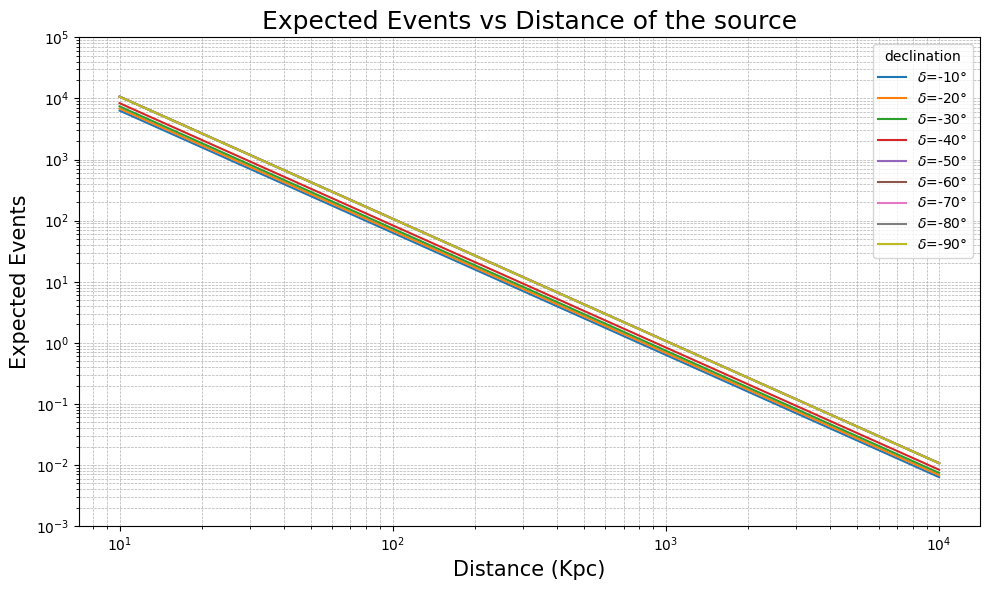

In [3]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
block_ranges = [(1, 51)]

# Lista per i risultati finali
Num_event_all_aeff = []

# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 2]

    
    # Creazione della funzione di interpolazione per l'area efficace

    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    positive_interp_aeff = lambda x: np.maximum(interpolation_function(x), 0)
    

    # Calcolo eventi per l'area efficace corrente
    Num_event = 0.0  # Reset per ogni aeff
    Num_tot = []     # Numero totale per ogni blocco
    n_ev = []        # Eventi attesi per ciascuna distanza

    print(f"Elaborazione per Aeff-{i}...")

    # Itera su ogni intervallo di blocchi
    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            # Estrai il numero di blocco dal nome del file
            block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
            
            # Controlla se il blocco rientra nel range corrente
            if start_block <= block_number <= end_block:
                # Calcola S_IIn basato sul numero di blocco
                S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
                S_IIn_stop = 1e5 * pow(10., 0.1 * (block_number))

                delta_t = S_IIn_stop - S_IIn_start
                
                if S_IIn_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                # Carica i dati dal file .dat
                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    Ev = Ev_all[Ev_all > 3e8]/1e9
                    dN_dEv = new_data[:, 7][Ev_all > 3e8]
                    dN_dEv = dN_dEv * (1 / 6*1e9)  
                    
                    lunghezza_Ev = len(Ev)
                    time = np.linspace(S_IIn_start, 1e8, lunghezza_Ev)
                    
                    
                    interpolation_flux = PchipInterpolator(Ev, dN_dEv, extrapolate=True)

                    

                    #interpolation_flux = interp1d(Ev, dN_dEv, kind='cubic', fill_value="extrapolate")
                    E_new = np.linspace(Ev.min(), Ev.max(), 500)
                
                    #flux_new = interpolation_flux(E_new)

                    # Definizione dell'integranda
                    def integranda(e):
                        flux = interpolation_flux(e) 
                        aeff = interpolation_function(e) # Usa l'area effettiva corrente
                        
                        return flux * aeff
                    
                    # Calcola l'integrale dell'energia
                    integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)

                    N_k = integrale_energia * delta_t  # Ponderazione per l'istante temporale t_start_k
                    #print(delta_t)
                    #print(flux_new)
                    #print(integrale_energia)
                    # Aggiorna il numero totale di eventi attesi
                    Num_event += N_k
                    Num_tot.append(N_k)
                    
                    time_all_P.append(block_number) 

    # Calcolo del numero di eventi attesi per ogni distanza
    d_min = 10 * 3.086e19  # 10 pc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

    n_ev_per_aeff = []
    for d in d_values:
        geom_con = 1 / (4 * np.pi * d ** 2)
        expected_events = Num_event * geom_con
        n_ev_per_aeff.append(expected_events)
    
    # Salva i risultati per l'area effettiva corrente
    Num_event_all_aeff.append({
        "aeff": f"$\delta$=-{i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values
    })

# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))

for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Mpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3,1e5)
plt.show()


In [4]:
import numpy as np

def print_results_for_distance(Num_event_all_aeff, distance_m):
    """
    Stampa il numero di eventi per tutte le Aeff a una distanza (in metri) scelta.
    Cerca l'indice di d_values più vicino alla distanza specificata.
    """
    print(f"\n=== Risultati per distanza = {distance_m:.3e} m ===")
    for res in Num_event_all_aeff:
        aeff_label = res["aeff"]
        d_vals = res["d_values"]
        n_ev = res["n_ev"]
        
        # Trova l'indice del valore di distanza più vicino a distance_m
        idx = np.argmin(np.abs(d_vals - distance_m))
        d_sel = d_vals[idx]
        nev_sel = n_ev[idx]
        
        print(f"Aeff: {aeff_label:>10s} | Distanza più vicina = {d_sel:.3e} m | n_ev = {nev_sel:.3e}")

# Esempio d'uso:
# Se vuoi i risultati a 1e20 metri (per dire):
print_results_for_distance(Num_event_all_aeff, distance_m=1*3.086e22)



=== Risultati per distanza = 3.086e+22 m ===
Aeff: $\delta$=-10° | Distanza più vicina = 3.086e+22 m | n_ev = 6.322e-01
Aeff: $\delta$=-20° | Distanza più vicina = 3.086e+22 m | n_ev = 6.831e-01
Aeff: $\delta$=-30° | Distanza più vicina = 3.086e+22 m | n_ev = 7.419e-01
Aeff: $\delta$=-40° | Distanza più vicina = 3.086e+22 m | n_ev = 8.364e-01
Aeff: $\delta$=-50° | Distanza più vicina = 3.086e+22 m | n_ev = 1.070e+00
Aeff: $\delta$=-60° | Distanza più vicina = 3.086e+22 m | n_ev = 1.074e+00
Aeff: $\delta$=-70° | Distanza più vicina = 3.086e+22 m | n_ev = 1.070e+00
Aeff: $\delta$=-80° | Distanza più vicina = 3.086e+22 m | n_ev = 1.066e+00
Aeff: $\delta$=-90° | Distanza più vicina = 3.086e+22 m | n_ev = 1.066e+00


First time


Elaborazione per Aeff-10...


C:\Users\Asus\AppData\Local\Temp\ipykernel_17200\915813225.py:66: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, Ev.min(), Ev.max(), limit=200)


Elaborazione per Aeff-20...
Elaborazione per Aeff-30...
Elaborazione per Aeff-40...
Elaborazione per Aeff-50...
Elaborazione per Aeff-60...


C:\Users\Asus\AppData\Local\Temp\ipykernel_17200\915813225.py:66: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integrale_energia, _ = spi.quad(integranda, Ev.min(), Ev.max(), limit=200)


Elaborazione per Aeff-70...
Elaborazione per Aeff-80...
Elaborazione per Aeff-90...


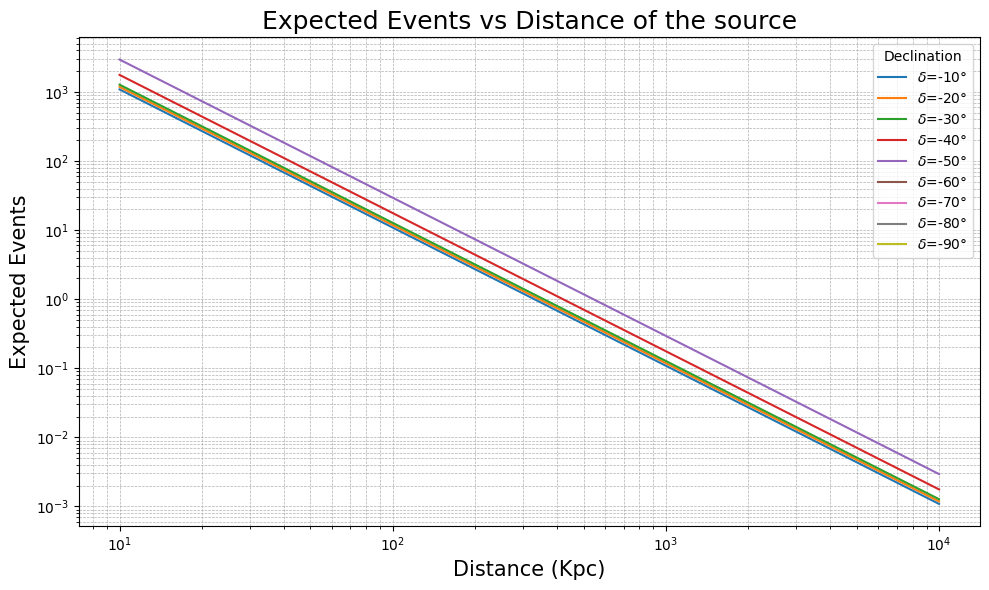

In [4]:
import matplotlib.pyplot as plt
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d


# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
block_ranges = [(1, 51)]

# Lista per i risultati finali
Num_event_all_aeff = []
# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Interpolazione dell'area efficace
    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Inizializziamo la somma su tutti i blocchi
    Num_event = 0.0  
    Num_tot = []     

    print(f"Elaborazione per Aeff-{i}...")

    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
            
            if start_block <= block_number <= end_block:
                S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
                S_IIn_stop = 1e5 * pow(10., 0.1 * (block_number))
                delta_t = S_IIn_stop - S_IIn_start
                
                if S_IIn_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    Ev = Ev_all[Ev_all > 3e8]  # Seleziona energie > 300 MeV
                    dN_dEv = new_data[:, 7][Ev_all > 3e8] * (1 / 3)  

                    # Somma in tempo per ogni energia
                    flux_temporale = dN_dEv * delta_t  

                    # Interpolazione in energia
                    interpolation_flux = interp1d(Ev, flux_temporale, kind='linear', fill_value="extrapolate")

                    # Definizione dell'integranda in energia
                    def integranda(e):
                        flux = interpolation_flux(e) / 1e9  # Normalizza
                        aeff = interpolation_function(e)    # Area efficace
                        return flux * aeff
                    
                    # Integriamo in energia dopo la somma temporale
                    integrale_energia, _ = spi.quad(integranda, Ev.min(), Ev.max(), limit=200)

                    Num_event += integrale_energia
                    Num_tot.append(integrale_energia)

    # Calcolo del numero di eventi attesi per ogni distanza
    d_min = 10 * 3.086e19  # 10 Kpc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

    n_ev_per_aeff = [Num_event * (1 / (4 * np.pi * d ** 2)) for d in d_values]
    
    # Salviamo i risultati
    Num_event_all_aeff.append({
        "aeff": f"$\delta$=-{i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values
    })

# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))
#for result in Num_event_all_aeff:
    #result["n_ev"] = [max(0, val) for val in result["n_ev"]]

for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Mpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="Declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
#plt.ylim(1e-3, 1e4)
plt.show()


In [5]:
import numpy as np

def print_results_for_distance(Num_event_all_aeff, distance_m):
    """
    Stampa il numero di eventi per tutte le Aeff a una distanza (in metri) scelta.
    Cerca l'indice di d_values più vicino alla distanza specificata.
    """
    print(f"\n=== Risultati per distanza = {distance_m:.3e} m ===")
    for res in Num_event_all_aeff:
        aeff_label = res["aeff"]
        d_vals = res["d_values"]
        n_ev = res["n_ev"]
        
        # Trova l'indice del valore di distanza più vicino a distance_m
        idx = np.argmin(np.abs(d_vals - distance_m))
        d_sel = d_vals[idx]
        nev_sel = n_ev[idx]
        
        print(f"Aeff: {aeff_label:>10s} | Distanza più vicina = {d_sel:.3e} m | n_ev = {nev_sel:.3e}")

# Esempio d'uso:
# Se vuoi i risultati a 1e20 metri (per dire):
print_results_for_distance(Num_event_all_aeff, distance_m=10*3.086e19)



=== Risultati per distanza = 3.086e+20 m ===
Aeff: $\delta$=-10° | Distanza più vicina = 3.086e+20 m | n_ev = 1.088e+03
Aeff: $\delta$=-20° | Distanza più vicina = 3.086e+20 m | n_ev = 1.185e+03
Aeff: $\delta$=-30° | Distanza più vicina = 3.086e+20 m | n_ev = 1.274e+03
Aeff: $\delta$=-40° | Distanza più vicina = 3.086e+20 m | n_ev = 1.764e+03
Aeff: $\delta$=-50° | Distanza più vicina = 3.086e+20 m | n_ev = 2.943e+03
Aeff: $\delta$=-60° | Distanza più vicina = 3.086e+20 m | n_ev = -1.787e+02
Aeff: $\delta$=-70° | Distanza più vicina = 3.086e+20 m | n_ev = -3.718e+02
Aeff: $\delta$=-80° | Distanza più vicina = 3.086e+20 m | n_ev = -1.162e+02
Aeff: $\delta$=-90° | Distanza più vicina = 3.086e+20 m | n_ev = -1.162e+02


In [ ]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Lista per i risultati finali relativi agli eventi attesi
Num_event_all_aeff = []
block_ranges = [(1, 51)]

# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    # Caricamento e interpolazione dell'area efficace
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Inizializziamo variabili per eventi e per accumulare i profili flux_temporale
    Num_event = 0.0  
    Num_tot = []     
    energy_list = []  # Lista degli array di energia per ogni blocco valido
    flux_list = []    # Lista dei corrispondenti flux_temporale (dN/dE * delta_t)

    print(f"Elaborazione per Aeff-{i}...")
    
    # Loop sui blocchi definiti
    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            # Estrai il numero di blocco dal nome del file
            block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
            
            if start_block <= block_number <= end_block:
                S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
                S_IIn_stop  = 1e5 * pow(10., 0.1 * (block_number))
                delta_t     = S_IIn_stop - S_IIn_start
                
                if S_IIn_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    # Seleziona energie > 300 MeV
                    Ev = Ev_all[Ev_all > 3e8]
                    dN_dEv = new_data[:, 7][Ev_all > 3e8] * (1 / 3)
                    
                    # Calcola il contributo temporale per ogni energia
                    flux_temporale = dN_dEv * delta_t  
                    
                    # Accumula i dati per il plot (per avere una funzione flux vs E globale)
                    energy_list.append(Ev)
                    flux_list.append(flux_temporale)
                    
                    # Ora costruiamo l'interpolazione in energia per questo blocco
                    interpolation_flux = interp1d(Ev, flux_temporale, kind='cubic', fill_value="extrapolate")
                    
                    # Definizione dell'integranda in energia (con normalizzazione, se desiderata)
                    def integranda(e):
                        flux = interpolation_flux(e) / 1e9  # ad es. normalizzo dividendo per 1e9
                        aeff = interpolation_function(e)
                        return flux * aeff
                    
                    # Integrazione in energia per il blocco corrente
                    integrale_energia, _ = spi.quad(integranda, Ev.min(), Ev.max(), limit=200)
                    Num_event += integrale_energia
                    Num_tot.append(integrale_energia)
    
    # Calcolo del numero di eventi attesi per distanza (come nel tuo codice originale)
    d_min = 10 * 3.086e19  # 10 pc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  
    n_ev_per_aeff = [Num_event * (1 / (4 * np.pi * d ** 2)) for d in d_values]
    
    # Salva i risultati degli eventi attesi
    Num_event_all_aeff.append({
        "aeff": f"$\delta$=-{i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values
    })
    
    # --------- Calcolo e Plot del profilo globale di flux_temporale vs Energia --------- #
    if len(energy_list) > 0:
        # Determina l'intervallo globale di energia tra tutti i blocchi
        global_E_min = min(e.min() for e in energy_list)
        global_E_max = max(e.max() for e in energy_list)
        E_plot = np.linspace(global_E_min, global_E_max, 500)
        flux_sum = np.zeros_like(E_plot)
        
        # Somma i contributi interpolati su una griglia comune
        for Ev, flux_temp in zip(energy_list, flux_list):
            interp_func = interp1d(Ev, flux_temp, kind='cubic', fill_value="extrapolate")
            flux_sum += interp_func(E_plot)
        
        # Plot del flux temporale globale
        plt.figure(figsize=(8, 5))
        plt.plot(E_plot, flux_sum, label=f"Aeff-{i}")
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel("Energy", fontsize=14)
        plt.ylabel("Flux temporale (dN/dE * Δt)", fontsize=14)
        plt.title(f"Flux temporale vs Energy per Aeff-{i}", fontsize=16)
        plt.legend()
        plt.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()
        
        # Salva i dati in un file di testo (due colonne: Energy e flux_temporale)
        filename = f"flux_temporale_vs_energy_aeff_{i}.txt"
        np.savetxt(filename, np.column_stack((E_plot, flux_sum)), 
                   header='Energy\tFlux_temporale', comments='# ')
        print(f"Salvati i dati di flux_temporale vs Energy in {filename}")

# ---------------- Plot degli eventi attesi vs distanza (come nel codice originale) ---------------- #
plt.figure(figsize=(10, 6))
for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Kpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="Declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3, 1e4)
plt.show()


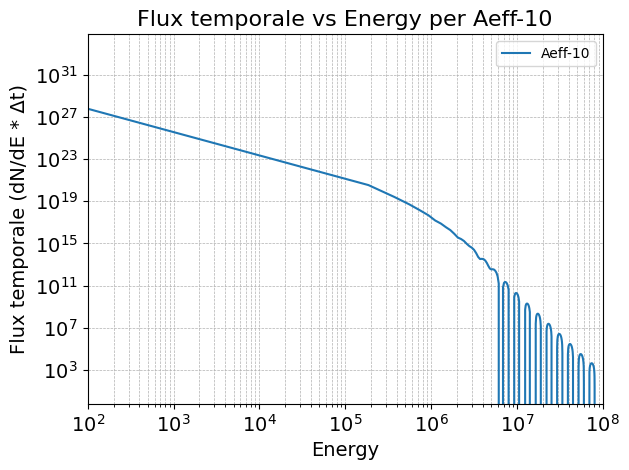

In [26]:
filename = np.loadtxt("flux_temporale_vs_energy_aeff_10.txt")
E_plot = filename[:, 0]
flux_sum = filename[:, 1]

plt.plot(E_plot/1e9, flux_sum/1e9, label=f"Aeff-10")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e2,1e8)
plt.xlabel("Energy", fontsize=14)
plt.ylabel("Flux temporale (dN/dE * Δt)", fontsize=14)
plt.title(f"Flux temporale vs Energy per Aeff-10", fontsize=16)
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


MODEL REJECTION FACTOR (PROVA)

Elaborazione per Aeff-10...
Elaborazione per Aeff-20...
Elaborazione per Aeff-30...
Elaborazione per Aeff-40...
Elaborazione per Aeff-50...
Elaborazione per Aeff-60...
Elaborazione per Aeff-70...
Elaborazione per Aeff-80...
Elaborazione per Aeff-90...


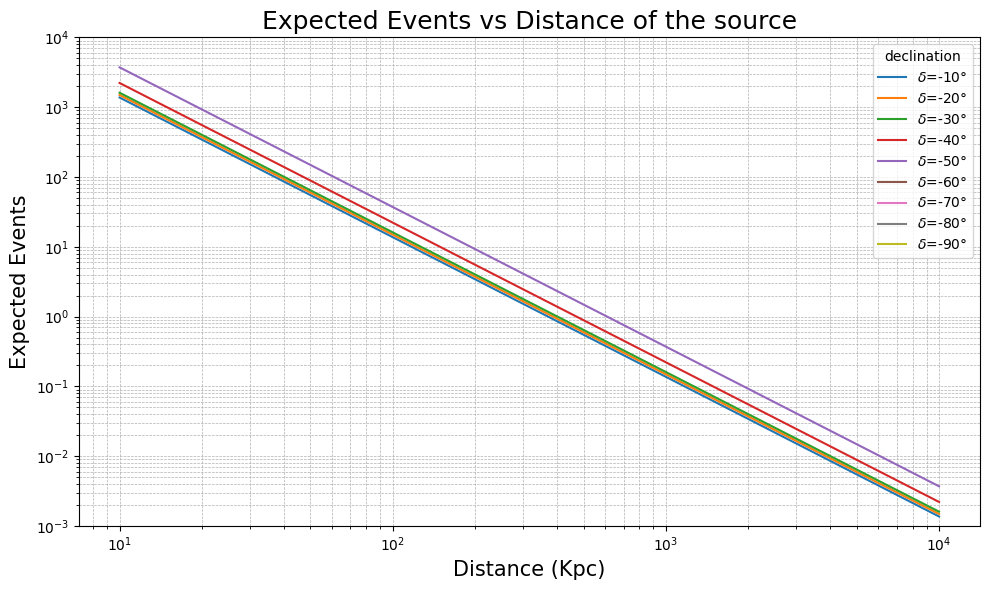

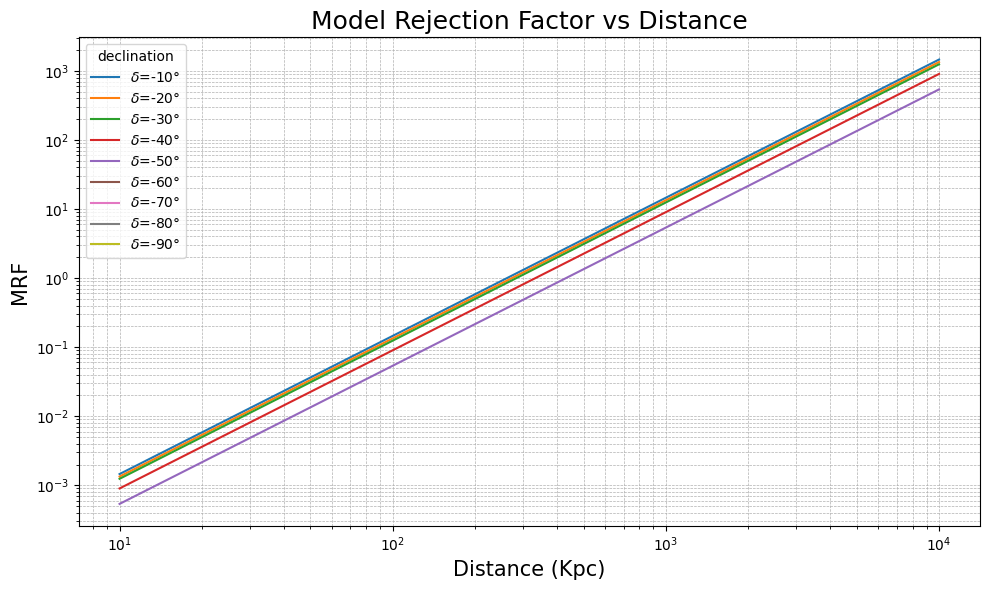

In [12]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
block_ranges = [(1, 51)]

# Lista per i risultati finali
Num_event_all_aeff = []

# Funzione per stimare il limite superiore N_limit a 90% C.L. usando la distribuzione di Poisson
def poisson_upper_limit(n_obs, confidence_level=0.9):
    """
    Calcola il limite superiore per una distribuzione di Poisson
    a un dato livello di confidenza.
    """
    return poisson.ppf(confidence_level, n_obs + 1)  # Aggiungiamo 1 per evitare zero puro

# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Creazione della funzione di interpolazione per l'area efficace
    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Calcolo eventi per l'area efficace corrente
    Num_event = 0.0  # Reset per ogni aeff
    Num_tot = []     # Numero totale per ogni blocco
    n_ev = []        # Eventi attesi per ciascuna distanza

    print(f"Elaborazione per Aeff-{i}...")

    # Itera su ogni intervallo di blocchi
    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
            
            if start_block <= block_number <= end_block:
                S_IIn_start = 1e5 * pow(10., 0.1 * (block_number - 1))
                S_IIn_stop = 1e5 * pow(10., 0.1 * (block_number))
                delta_t = S_IIn_stop - S_IIn_start
                
                if S_IIn_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    Ev = Ev_all[Ev_all > 3e8]
                    dN_dEv = new_data[:, 7][Ev_all > 3e8] * (1 / 3)
                    
                    interpolation_flux = interp1d(Ev, dN_dEv, kind='cubic', fill_value="extrapolate")
                    E_new = np.linspace(Ev.min(), Ev.max(), 500)

                    def integranda(e):
                        return interpolation_flux(e) / 1e9 * interpolation_function(e)

                    integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)
                    N_k = integrale_energia * delta_t  
                    Num_event += N_k
                    Num_tot.append(N_k)

    # Calcolo del numero di eventi attesi per ogni distanza
    d_min = 10 * 3.086e19  # 10 pc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

    n_ev_per_aeff = []
    mrf_per_aeff = []

    for d in d_values:
        geom_con = 1 / (4 * np.pi * d ** 2)
        expected_events = Num_event * geom_con
        n_ev_per_aeff.append(expected_events)

        # Calcolo MRF usando il limite superiore di Poisson a 90% C.L.
        N_limit = poisson_upper_limit(0)  # Supponiamo zero eventi osservati
        mrf = N_limit / expected_events if expected_events > 0 else np.inf
        mrf_per_aeff.append(mrf)
    
    Num_event_all_aeff.append({
        "aeff": f"$\delta$=-{i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values,
        "mrf": mrf_per_aeff
    })

# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))
for result in Num_event_all_aeff:
    plt.plot(result["d_values"] / 3.086e19, result["n_ev"], label=result["aeff"])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3, 1e4)
plt.show()

# Plot del Model Rejection Factor
plt.figure(figsize=(10, 6))
for result in Num_event_all_aeff:
    plt.plot(result["d_values"] / 3.086e19, result["mrf"], label=result["aeff"])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('MRF', fontsize=15)
plt.title('Model Rejection Factor vs Distance', fontsize=18)
plt.legend(title="declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


Aeff-10: N_limit = 2.00, <N_signal> = 1.64e+45, bkg = 2.66e-22
Aeff-20: N_limit = 2.00, <N_signal> = 1.79e+45, bkg = 2.73e-22
Aeff-30: N_limit = 2.00, <N_signal> = 1.93e+45, bkg = 2.90e-22
Aeff-40: N_limit = 2.00, <N_signal> = 2.66e+45, bkg = 3.33e-22
Aeff-50: N_limit = 2.00, <N_signal> = 4.45e+45, bkg = 4.65e-22
Aeff-60: N_limit = 2.00, <N_signal> = -2.32e+44, bkg = 4.50e-22
Aeff-70: N_limit = 2.00, <N_signal> = -5.34e+44, bkg = 4.48e-22
Aeff-80: N_limit = 2.00, <N_signal> = -1.69e+44, bkg = 4.41e-22
Aeff-90: N_limit = 2.00, <N_signal> = -1.69e+44, bkg = 4.41e-22


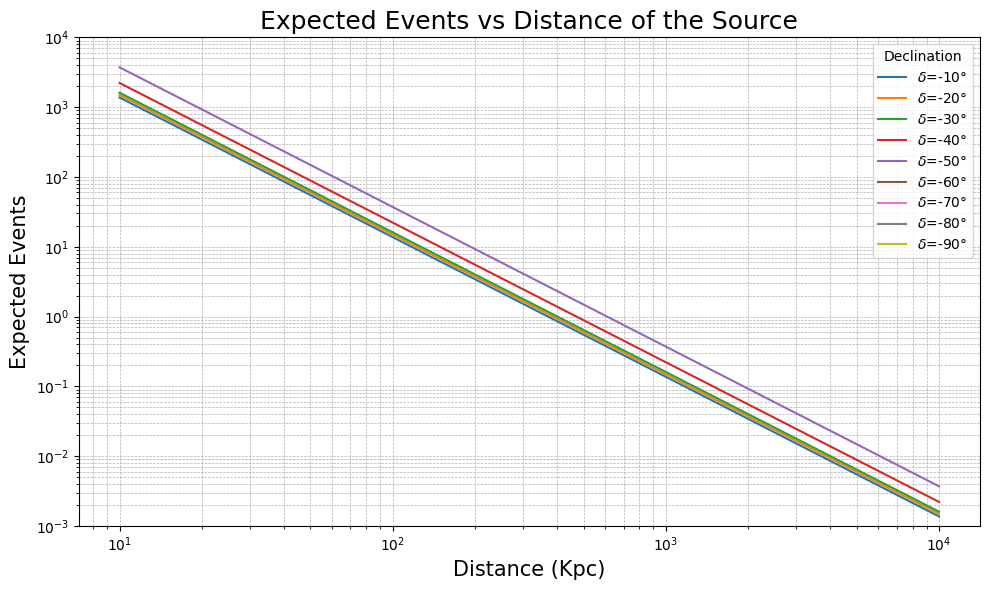

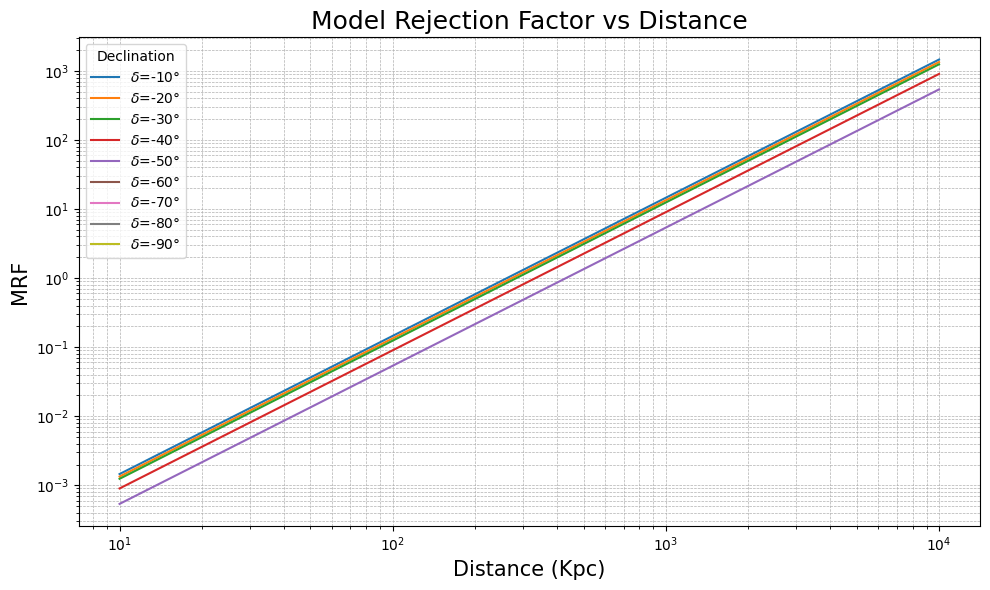

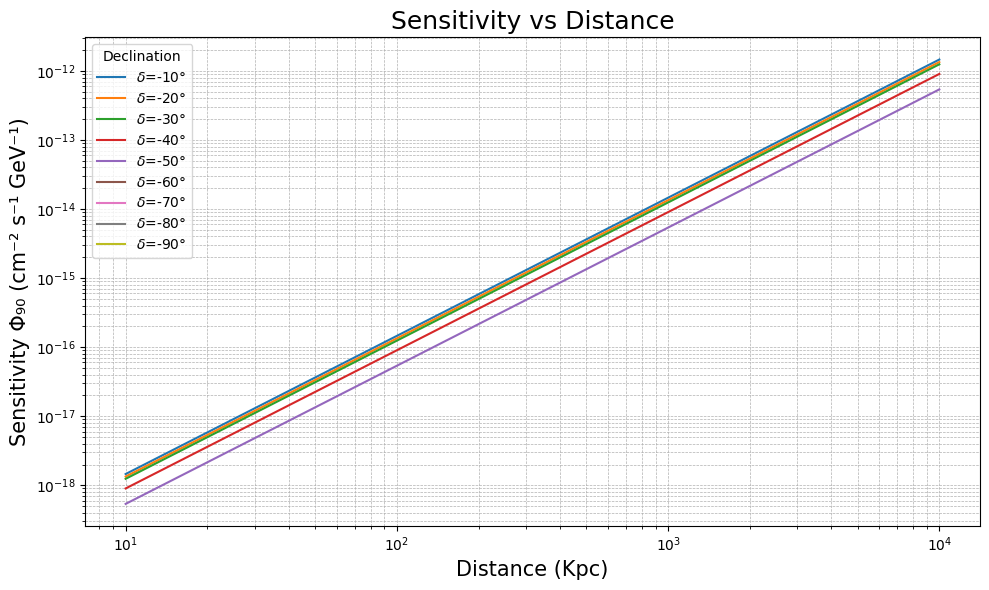

In [17]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.stats import poisson

# --- Parametri osservativi ---
T_obs = 1 * 365 * 24 * 3600  # 10 anni in secondi
sr = 2 * np.pi               # Steradianti per un emisfero

# --- Definisci il flusso modello usato per il calcolo degli eventi ---
# Sostituisci questo valore con la normalizzazione reale del tuo modello (unità ad es. cm⁻² s⁻¹ GeV⁻¹)
Phi_model = 1e-15  

# --- Funzione per il flusso di neutrini atmosferici ---
def phi_atm(E):
    # E in GeV; flusso in cm⁻² s⁻¹ sr⁻¹ GeV⁻¹
    return 1.95e-18 * (E)**(-3.7)

# --- Funzione per calcolare il limite sul segnale in presenza di background ---
def poisson_signal_limit(bkg, confidence_level=0.9):
    # Limite sul segnale a 90% CL, assumendo di osservare 0 eventi (con background bkg)
    return poisson.ppf(confidence_level, bkg + 1) - bkg

# --- Recupero dei file dati ---
file_list = glob.glob('SN_IIn/SNIIn_20_block_*.dat')
block_ranges = [(1, 51)]  # intervallo dei blocchi da considerare

# Lista per i risultati finali per ciascuna area efficace
Num_event_all_aeff = []

# Ciclo sulle aree efficaci (da Aeff-10 a Aeff-90)
for i in range(10, 100, 10):
    # Caricamento dell'area efficace
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1)
    En = 10**(aeff_data[:, 0])  # Conversione da log10(E) a E (GeV)
    Aeff = aeff_data[:, 3]       # Area efficace in cm²

    # Creazione della funzione di interpolazione per l'area efficace
    interp_aeff = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Calcolo degli eventi segnale (N_signal) per questa Aeff
    Num_event = 0.0
    Num_tot = []  # Eventi per ciascun blocco
    for start_block, end_block in block_ranges:
        for file_name in file_list:
            block_number = int(file_name.split('SNIIn_20_block_')[-1].split('.')[0])
            if start_block <= block_number <= end_block:
                S_IIn_start = 1e5 * 10**(0.1 * (block_number - 1))
                S_IIn_stop  = 1e5 * 10**(0.1 * block_number)
                delta_t = S_IIn_stop - S_IIn_start
                if S_IIn_start > 1e8:
                    continue
                new_data = np.loadtxt(file_name)
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    # Seleziona energie maggiori di 3e8 (unità compatibili con il file)
                    Ev = Ev_all[Ev_all > 3e8]
                    # Calcola dN/dEv e applica il fattore (1/3)
                    dN_dEv = new_data[:, 7][Ev_all > 3e8] * (1/3)
                    
                    # Interpolazione del flusso della sorgente (usato per il calcolo degli eventi)
                    interp_flux = interp1d(Ev, dN_dEv, kind='cubic', fill_value="extrapolate")
                    E_new = np.linspace(Ev.min(), Ev.max(), 500)
                    
                    # Definizione dell'integranda per il segnale:
                    # Dividiamo per 1e9 per convertire le unità (ad es. da eV a GeV)
                    def integrand(e):
                        return interp_flux(e) / 1e9 * interp_aeff(e)
                    
                    integral, _ = spi.quad(integrand, E_new.min(), E_new.max(), limit=200)
                    N_k = integral * delta_t
                    Num_event += N_k
                    Num_tot.append(N_k)
    
    # --- Calcolo del background atmosferico ---
    E_min = En.min()
    E_max = En.max()
    def integrand_bkg(E):
        return phi_atm(E) * interp_aeff(E)
    bkg_integral, _ = spi.quad(integrand_bkg, E_min, E_max, limit=200)
    # Numero di eventi di background attesi in 10 anni e su 2π sr
    bkg = T_obs * sr * bkg_integral
    
    # Calcolo del limite sul segnale a 90% CL in presenza di background
    N_limit = poisson_signal_limit(bkg)
    
    # --- Calcolo del segnale atteso in funzione della distanza e MRF ---
    d_min = 10 * 3.086e19   # 10 pc in metri
    d_max = 10 * 3.086e22   # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)
    n_ev_per_aeff = []  # Segnale atteso per ogni distanza
    mrf_per_aeff = []   # MRF per ogni distanza
    for d in d_values:
        geom_con = 1 / (4 * np.pi * d**2)
        expected_signal = Num_event * geom_con
        n_ev_per_aeff.append(expected_signal)
        mrf = N_limit / expected_signal if expected_signal > 0 else np.inf
        mrf_per_aeff.append(mrf)
    
    # --- Calcolo della sensitivity ---
    # Ora usiamo il flusso modello corretto:
    # La sensitivity in termini di flusso è data da: Φ₉₀ = Φ_model * MRF.
    sensitivity_per_aeff = [Phi_model * mrf for mrf in mrf_per_aeff]
    
    print(f"Aeff-{i}: N_limit = {N_limit:.2f}, <N_signal> = {Num_event:.2e}, bkg = {bkg:.2e}")
    Num_event_all_aeff.append({
        "aeff": f"$\delta$=-{i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values,
        "mrf": mrf_per_aeff,
        "sensitivity": sensitivity_per_aeff,
        "bkg": bkg,
        "N_limit": N_limit
    })

# --- Plot degli eventi attesi in funzione della distanza ---
plt.figure(figsize=(10, 6))
for result in Num_event_all_aeff:
    plt.plot(result["d_values"] / 3.086e19, result["n_ev"], label=result["aeff"])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the Source', fontsize=18)
plt.legend(title="Declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3, 1e4)
plt.show()

# --- Plot del Model Rejection Factor ---
plt.figure(figsize=(10, 6))
for result in Num_event_all_aeff:
    plt.plot(result["d_values"] / 3.086e19, result["mrf"], label=result["aeff"])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('MRF', fontsize=15)
plt.title('Model Rejection Factor vs Distance', fontsize=18)
plt.legend(title="Declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Plot della Sensitivity ---
plt.figure(figsize=(10, 6))
for result in Num_event_all_aeff:
    plt.plot(result["d_values"] / 3.086e19, result["sensitivity"], label=result["aeff"])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Sensitivity Φ₉₀ (cm⁻² s⁻¹ GeV⁻¹)', fontsize=15)
plt.title('Sensitivity vs Distance', fontsize=18)
plt.legend(title="Declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


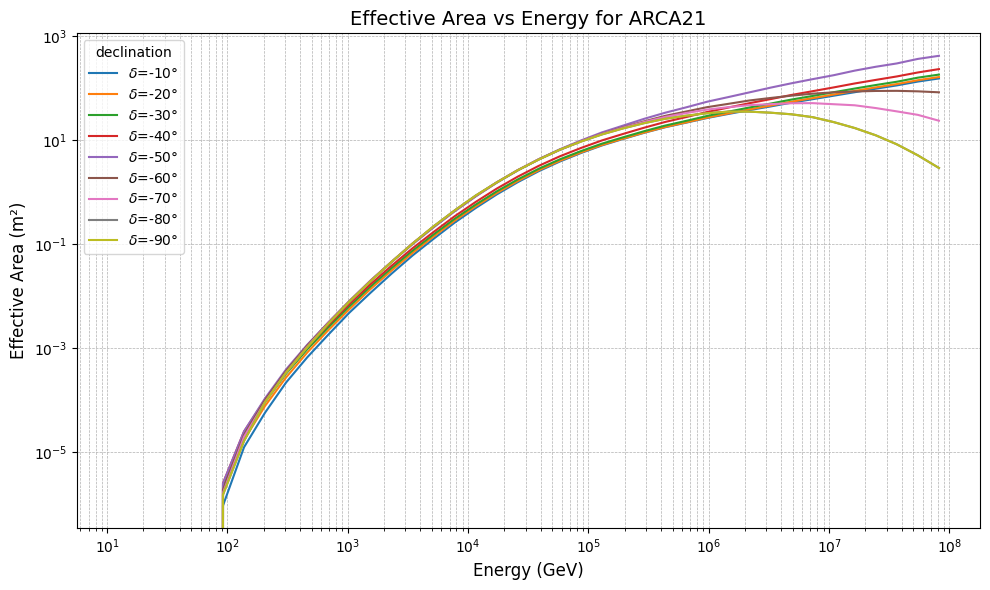

35.5644


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Figura per il plot di Aeff vs En
plt.figure(figsize=(10, 6))

# Ciclo su tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
    En_log = aeff_data[:, 0]  # log10(E)
    En = 10**En_log          # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Plotta l'area efficace in funzione dell'energia
    plt.plot(En, Aeff, label=f"$\delta$=-{i}°")

# Dettagli del grafico
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (GeV)', fontsize=12)
plt.ylabel('Effective Area (m²)', fontsize=12)
plt.title('Effective Area vs Energy for ARCA21', fontsize=14)
plt.legend(title="declination")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

# Mostra il grafico
plt.show()
print(Aeff.max())



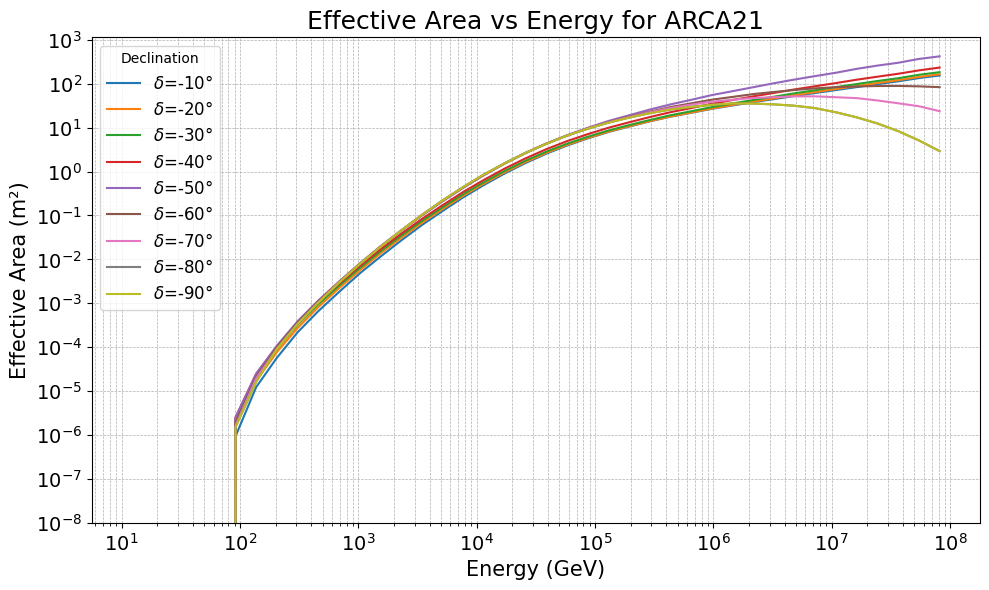

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Figura per il plot di Aeff vs En
fig, ax = plt.subplots(figsize=(10, 6))

# Ciclo su tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    try:
        # Caricamento dell'area efficace (Aeff)
        aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
        En_log = aeff_data[:, 0]  # log10(E)
        En = 10**En_log          # Conversione da log10(E) a E
        Aeff = aeff_data[:, 3]
        
        # Plotta l'area efficace in funzione dell'energia
        ax.plot(En, Aeff, label=f"$\delta$=-{i}°")
    except Exception as e:
        print(f"Errore nel caricamento del file Aeff/aeff-{i}.txt: {e}")



# Genera ticks logaritmici sull'asse y
yticks = np.logspace(-8, 3, num=12)  # Tick logaritmici uniformi


# Dettagli del grafico
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy (GeV)', fontsize=15)
ax.set_ylabel('Effective Area (m²)', fontsize=15)
ax.set_title('Effective Area vs Energy for ARCA21', fontsize=18)
ax.legend(title="Declination", fontsize=12)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.set_yticks(yticks)
# Layout
fig.tight_layout()

# Mostra il grafico
plt.show()




Elaborazione per Aeff-10...


C:\Users\Asus\AppData\Local\Temp\ipykernel_11148\2147434749.py:76: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)


Elaborazione per Aeff-20...
Elaborazione per Aeff-30...
Elaborazione per Aeff-40...
Elaborazione per Aeff-50...
Elaborazione per Aeff-60...
Elaborazione per Aeff-70...
Elaborazione per Aeff-80...
Elaborazione per Aeff-90...


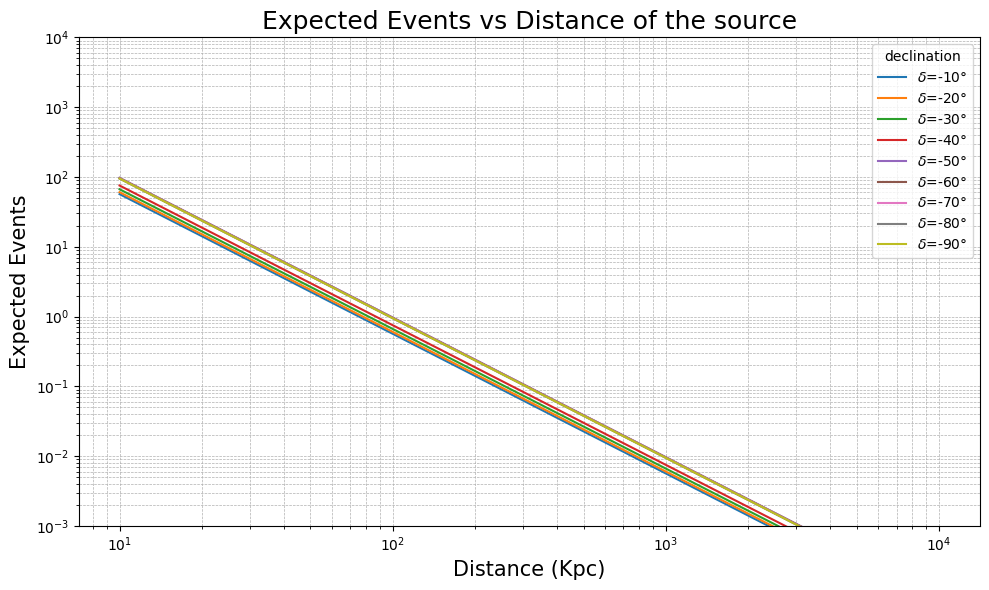

In [ ]:
import glob
import numpy as np
import scipy.integrate as spi
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Ottenere la lista di tutti i file .dat nella cartella SN_IIn
file_list = glob.glob('SN_IIP/SNIIP_20_block_*.dat')

# Vettore lightcurve e tempo per IIP S=2.0
time_all_P = []
flux_all_P = []
block_ranges = [(1, 51)]

# Lista per i risultati finali
Num_event_all_aeff = []

# Ciclo per tutte le aree efficaci (da aeff-10 a aeff-90)
for i in range(10, 100, 10):
    # Caricamento dell'area efficace (Aeff)
    aeff_data = np.genfromtxt(f'Aeff/aeff-{i}.txt', skip_header=1, delimiter=None)
    En = pow(10, aeff_data[:, 0])  # Conversione da log10(E) a E
    Aeff = aeff_data[:, 3]
    
    # Creazione della funzione di interpolazione per l'area efficace
    interpolation_function = interp1d(En, Aeff, kind='linear', fill_value="extrapolate")
    
    # Calcolo eventi per l'area efficace corrente
    Num_event = 0.0  # Reset per ogni aeff
    Num_tot = []     # Numero totale per ogni blocco
    n_ev = []        # Eventi attesi per ciascuna distanza

    print(f"Elaborazione per Aeff-{i}...")

    # Itera su ogni intervallo di blocchi
    for idx, (start_block, end_block) in enumerate(block_ranges, start=1):
        for file_name in file_list:
            # Estrai il numero di blocco dal nome del file
            block_number = int(file_name.split('SNIIP_20_block_')[-1].split('.')[0])
            
            # Controlla se il blocco rientra nel range corrente
            if start_block <= block_number <= end_block:
                # Calcola S_IIn basato sul numero di blocco
                S_IIp_start = 1e3 * pow(10., 0.1 * (block_number - 1))
                S_IIp_stop = 1e3 * pow(10., 0.1 * (block_number))

                delta_t = S_IIp_stop - S_IIp_start
                
                if S_IIn_start > 1e8:
                    print(f"Blocco {block_number} ignorato: S_n_start = {S_IIn_start} > 10^8") 
                    continue

                # Carica i dati dal file .dat
                new_data = np.loadtxt(file_name)
                
                if new_data[-1, -1] == 1:
                    Ev_all = new_data[:, 0]
                    Ev = Ev_all[Ev_all > 3e8]/1e9
                    dN_dEv = new_data[:, 7][Ev_all > 3e8]
                    dN_dEv = dN_dEv * (1 / 3*1e9)  
                    
                    lunghezza_Ev = len(Ev)
                    time = np.linspace(S_IIn_start, 1e8, lunghezza_Ev)

                    interpolation_flux = interp1d(Ev, dN_dEv, kind='linear', fill_value="extrapolate")
                    E_new = np.linspace(Ev.min(), Ev.max(), 500)
                    flux_new = interpolation_flux(E_new)

                    # Definizione dell'integranda
                    def integranda(e):
                        flux = interpolation_flux(e) 
                        aeff = interpolation_function(e)  # Usa l'area effettiva corrente
                        return flux * aeff
                    
                    # Calcola l'integrale dell'energia
                    integrale_energia, _ = spi.quad(integranda, E_new.min(), E_new.max(), limit=200)

                    N_k = integrale_energia * delta_t  # Ponderazione per l'istante temporale t_start_k
                    
                    # Aggiorna il numero totale di eventi attesi
                    Num_event += N_k
                    Num_tot.append(N_k)
                    
                    time_all_P.append(block_number) 

    # Calcolo del numero di eventi attesi per ogni distanza
    d_min = 10 * 3.086e19  # 10 Kpc in metri
    d_max = 10 * 3.086e22  # 10 Mpc in metri
    d_values = np.logspace(np.log10(d_min), np.log10(d_max), 100)  

    n_ev_per_aeff = []
    for d in d_values:
        geom_con = 1 / (4 * np.pi * d ** 2)
        expected_events = Num_event * geom_con
        n_ev_per_aeff.append(expected_events)
    
    # Salva i risultati per l'area effettiva corrente
    Num_event_all_aeff.append({
        "aeff": f"$\delta$=-{i}°",
        "num_event": Num_event,
        "num_tot": Num_tot,
        "n_ev": n_ev_per_aeff,
        "d_values": d_values
    })

# Plot degli eventi attesi in funzione della distanza
plt.figure(figsize=(10, 6))

for result in Num_event_all_aeff:
    d_values = result["d_values"]
    n_ev = result["n_ev"]
    aeff_label = result["aeff"]
    
    plt.plot(d_values / 3.086e19, n_ev, label=aeff_label)  # Converti distanza in Mpc

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distance (Kpc)', fontsize=15)
plt.ylabel('Expected Events', fontsize=15)
plt.title('Expected Events vs Distance of the source', fontsize=18)
plt.legend(title="declination")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.ylim(1e-3,1e5)
plt.show()
